# ML Course Season 2
## Практика: Подбор гиперпараметров и интерпретируемость моделей

В этом ноутбуке мы:
1. Подберём гиперпараметры нескольких моделей с помощью Grid Search и Random Search
2. Настроим Pipeline с совместным подбором препроцессинга и модели
3. Интерпретируем результаты через Permutation Importance, PDP/ICE и SHAP
4. Научимся диагностировать подозрительные признаки

**Датасет:** [Wine Quality](https://scikit-learn.org/stable/datasets/toy_dataset.html) и Breast Cancer Wisconsin (sklearn)

---

## Шаг 1. Импорты и загрузка данных

Загрузим датасет Breast Cancer Wisconsin и познакомимся с ним.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Загружаем датасет
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = data.feature_names

print(data.DESCR[:600])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concav


In [3]:
# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")

Train: (455, 30), Test: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Базовые модели без тюнинга

Обучим несколько моделей с дефолтными параметрами, чтобы иметь точку отсчёта.

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

# Словарь базовых моделей
base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42))]),
}

baseline_results = {}

# ╔══════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 2а: Для каждой модели в base_models         ║
# ║  вычислите 5-fold CV с scoring='f1_macro'            ║
# ║  Сохраните mean и std в baseline_results             ║
# ╚══════════════════════════════════════════════════════╝

for name, model in base_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro', n_jobs=-1)
    baseline_results[name] = (scores.mean(), scores.std())

# После заполнения — вывод результатов:
for name, (mean, std) in baseline_results.items():
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")

SVM                       F1 = 0.9694 ± 0.0193
RandomForest              F1 = 0.9504 ± 0.0255
LogisticRegression        F1 = 0.9787 ± 0.0139


## Шаг 3. Grid Search для SVM

Подберём гиперпараметры SVM с помощью перебора сетки через Pipeline.

In [5]:
from sklearn.model_selection import GridSearchCV

# Pipeline: нормировка + SVM
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)),
])

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3а: Задайте сетку параметров для GridSearchCV       ║
# ║  Параметры SVM через Pipeline: 'svm__C', 'svm__gamma',       ║
# ║  'svm__kernel'                                               ║
# ║  Попробуйте: C in [0.1, 1, 10, 100],                        ║
# ║  gamma in ['scale', 0.01, 0.001], kernel in ['rbf','linear'] ║
# ╚══════════════════════════════════════════════════════════════╝

svm_param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.01, 0.001],
    'svm__kernel': ['rbf', 'linear'],
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3б: Создайте и запустите GridSearchCV               ║
# ║  cv=5, scoring='f1_macro', n_jobs=-1                         ║
# ╚══════════════════════════════════════════════════════════════╝

svm_grid_search = GridSearchCV(
    estimator=svm_pipe,
    param_grid=svm_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    refit=True,
)
svm_grid_search.fit(X_train, y_train)

print(f"Лучшие параметры SVM: {svm_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_grid_search.best_score_:.4f}")

Лучшие параметры SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Лучший CV F1: 0.9786


In [6]:
# Анализируем результаты Grid Search

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3в: Создайте DataFrame из svm_grid_search.cv_results║
# ║  Выберите колонки: params, mean_test_score, std_test_score,  ║
# ║  rank_test_score                                             ║
# ║  Выведите топ-10 конфигураций                                ║
# ╚══════════════════════════════════════════════════════════════╝

svm_results_df = pd.DataFrame(svm_grid_search.cv_results_)[
    ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
].sort_values('rank_test_score')

display(svm_results_df.head(10))

,params,mean_test_score,std_test_score,rank_test_score
14,"{'svm__C': 10, 'svm__gamma': 0.01, 'svm__kerne...",0.978633,0.017581,1
1,"{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__k...",0.976215,0.015266,2
5,"{'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__ker...",0.976215,0.015266,2
3,"{'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kern...",0.976215,0.015266,2
22,"{'svm__C': 100, 'svm__gamma': 0.001, 'svm__ker...",0.976157,0.016975,5
16,"{'svm__C': 10, 'svm__gamma': 0.001, 'svm__kern...",0.971340,0.016281,6
6,"{'svm__C': 1, 'svm__gamma': 'scale', 'svm__ker...",0.969357,0.019323,7
12,"{'svm__C': 10, 'svm__gamma': 'scale', 'svm__ke...",0.969350,0.019215,8
20,"{'svm__C': 100, 'svm__gamma': 0.01, 'svm__kern...",0.966936,0.017464,9
8,"{'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel...",0.966732,0.025212,10


## Шаг 4. Random Search для RandomForest

Теперь подберём гиперпараметры RandomForest с помощью случайного поиска.

In [7]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4а: Задайте пространство параметров для             ║
# ║  RandomizedSearchCV на RandomForestClassifier                ║
# ║  Попробуйте:                                                 ║
# ║    n_estimators: randint(50, 500)                            ║
# ║    max_depth: randint(2, 20) или None                        ║
# ║    min_samples_split: randint(2, 20)                         ║
# ║    max_features: ['sqrt', 'log2', 0.5]                       ║
# ╚══════════════════════════════════════════════════════════════╝

rf_param_dist = {
    'n_estimators': randint(50, 500),
    'max_depth': [None] + list(range(2, 20)),
    'min_samples_split': randint(2, 20),
    'max_features': ['sqrt', 'log2', 0.5],
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4б: Создайте RandomizedSearchCV                     ║
# ║  n_iter=50, cv=5, scoring='f1_macro',                        ║
# ║  random_state=42, n_jobs=-1                                  ║
# ║  Обучите на X_train, y_train                                 ║
# ╚══════════════════════════════════════════════════════════════╝

rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=50,
    cv=5,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1,
    refit=True,
)
rf_random_search.fit(X_train, y_train)

print(f"Лучшие параметры RF: {rf_random_search.best_params_}")
print(f"Лучший CV F1: {rf_random_search.best_score_:.4f}")

Лучшие параметры RF: {'max_depth': 19, 'max_features': 0.5, 'min_samples_split': 4, 'n_estimators': 356}
Лучший CV F1: 0.9554


## Шаг 5. Сравнение результатов

Сравним: baseline vs Grid Search vs Random Search. И проведём финальную оценку на тесте.

In [8]:
from sklearn.metrics import classification_report

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 5: Оцените лучшие модели (svm_grid_search и         ║
# ║  rf_random_search) на тестовой выборке X_test, y_test        ║
# ║                                                              ║
# ║  Для каждой модели выведите classification_report            ║
# ║  Сравните с baseline моделями из шага 2                      ║
# ║                                                              ║
# ║  ВАЖНО: тест используем ТОЛЬКО ЗДЕСЬ, один раз!             ║
# ╚══════════════════════════════════════════════════════════════╝

svm_baseline = base_models['SVM'].fit(X_train, y_train)
rf_baseline = base_models['RandomForest'].fit(X_train, y_train)
svm_best = svm_grid_search.best_estimator_
rf_best = rf_random_search.best_estimator_

models_for_test = {
    'SVM baseline': svm_baseline,
    'SVM Grid Search': svm_best,
    'RF baseline': rf_baseline,
    'RF Random Search': rf_best,
}

test_f1_scores = {}
for model_name, model in models_for_test.items():
    y_pred = model.predict(X_test)
    test_f1 = f1_score(y_test, y_pred, average='macro')
    test_f1_scores[model_name] = test_f1
    print(f"\n=== {model_name} ===")
    print(classification_report(y_test, y_pred))

comparison_df = pd.DataFrame([
    {
        'Модель': 'SVM baseline',
        'CV F1 (mean±std)': f"{baseline_results['SVM'][0]:.4f} ± {baseline_results['SVM'][1]:.4f}",
        'Test F1': f"{test_f1_scores['SVM baseline']:.4f}",
    },
    {
        'Модель': 'SVM Grid Search',
        'CV F1 (mean±std)': f"{svm_grid_search.best_score_:.4f} ± {svm_results_df.iloc[0]['std_test_score']:.4f}",
        'Test F1': f"{test_f1_scores['SVM Grid Search']:.4f}",
    },
    {
        'Модель': 'RF baseline',
        'CV F1 (mean±std)': f"{baseline_results['RandomForest'][0]:.4f} ± {baseline_results['RandomForest'][1]:.4f}",
        'Test F1': f"{test_f1_scores['RF baseline']:.4f}",
    },
    {
        'Модель': 'RF Random Search',
        'CV F1 (mean±std)': f"{rf_random_search.best_score_:.4f} ± n/a",
        'Test F1': f"{test_f1_scores['RF Random Search']:.4f}",
    },
])

display(comparison_df)

# Заполните таблицу:
# | Модель                | CV F1 (mean±std) | Test F1 |
# |-----------------------|------------------|---------|
# | SVM baseline          |                  |         |
# | SVM Grid Search       |                  |         |
# | RF baseline           |                  |         |
# | RF Random Search      |                  |         |


=== SVM baseline ===
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


=== SVM Grid Search ===
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


=== RF baseline ===
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weight

,Модель,CV F1 (mean±std),Test F1
0,SVM baseline,0.9694 ± 0.0193,0.9812
1,SVM Grid Search,0.9786 ± 0.0176,0.9812
2,RF baseline,0.9504 ± 0.0255,0.9526
3,RF Random Search,0.9554 ± n/a,0.9526


## Шаг 6. Permutation Importance

Посмотрим, какие признаки важны для лучшей модели.

,feature,importance_mean,importance_std
27,worst concave points,0.028624,0.009783
21,worst texture,0.010080,0.006399
7,mean concave points,0.009154,0.008154
23,worst area,0.008427,0.009737
13,area error,0.004593,0.004593
1,mean texture,0.003674,0.004500
26,worst concavity,0.002756,0.004209
22,worst perimeter,0.000892,0.007949
8,mean symmetry,0.000000,0.000000
4,mean smoothness,0.000000,0.000000


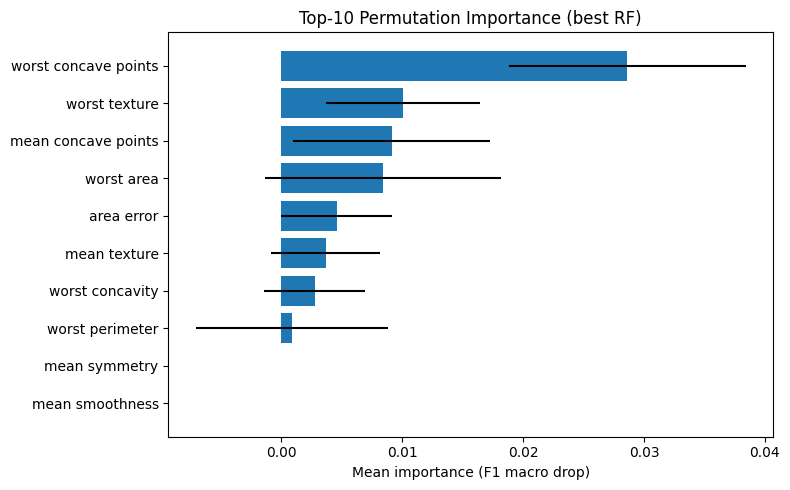

In [9]:
from sklearn.inspection import permutation_importance

# Используем лучший RF из Random Search
best_rf = rf_random_search.best_estimator_

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6а: Вычислите Permutation Importance                ║
# ║  для best_rf на X_test, y_test                               ║
# ║  n_repeats=10, random_state=42, scoring='f1_macro'           ║
# ╚══════════════════════════════════════════════════════════════╝

pi_result = permutation_importance(
    best_rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='f1_macro',
    n_jobs=-1,
)

pi_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': pi_result.importances_mean,
    'importance_std': pi_result.importances_std,
}).sort_values('importance_mean', ascending=False)

display(pi_df.head(10))

# Построим bar plot топ-10 признаков
top10_pi = pi_df.head(10).iloc[::-1]
plt.figure(figsize=(8, 5))
plt.barh(top10_pi['feature'], top10_pi['importance_mean'], xerr=top10_pi['importance_std'])
plt.title('Top-10 Permutation Importance (best RF)')
plt.xlabel('Mean importance (F1 macro drop)')
plt.tight_layout()
plt.show()

In [10]:
# Встроенная важность RF (для сравнения)

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6б: Сравните Permutation Importance                 ║
# ║  с встроенной feature_importances_ RandomForest              ║
# ║  Совпадает ли порядок топ-5 признаков?                       ║
# ║  Если нет — как вы это объясняете?                           ║
# ╚══════════════════════════════════════════════════════════════╝

rf_builtin_df = pd.DataFrame({
    'feature': X_test.columns,
    'rf_builtin_importance': best_rf.feature_importances_,
}).sort_values('rf_builtin_importance', ascending=False)

top5_pi = pi_df['feature'].head(5).tolist()
top5_builtin = rf_builtin_df['feature'].head(5).tolist()
intersection_top5 = sorted(set(top5_pi).intersection(set(top5_builtin)))

print('Top-5 по Permutation Importance:')
print(top5_pi)
print('\nTop-5 по встроенной feature_importances_:')
print(top5_builtin)
print(f"\nСовпавшие признаки в top-5: {intersection_top5}")
print(f"Совпало {len(intersection_top5)} из 5")

if top5_pi == top5_builtin:
    print('\nПорядок топ-5 полностью совпадает.')
else:
    print('\nПорядок топ-5 не полностью совпадает.')
    print('Объяснение: PI измеряет падение качества на валидационных данных при перемешивании признака,')
    print('а встроенная важность RF отражает вклад в разбиения деревьев на этапе обучения.')
    print('При коррелированных признаках или сложных взаимодействиях ранги могут различаться.')

# Вопрос для размышления:
# Некоторые признаки имеют высокий PI, но низкую встроенную важность,
# или наоборот. Что это может означать?

Top-5 по Permutation Importance:
['worst concave points', 'worst texture', 'mean concave points', 'worst area', 'area error']

Top-5 по встроенной feature_importances_:
['worst perimeter', 'worst concave points', 'worst area', 'worst radius', 'mean concave points']

Совпавшие признаки в top-5: ['mean concave points', 'worst area', 'worst concave points']
Совпало 3 из 5

Порядок топ-5 не полностью совпадает.
Объяснение: PI измеряет падение качества на валидационных данных при перемешивании признака,
а встроенная важность RF отражает вклад в разбиения деревьев на этапе обучения.
При коррелированных признаках или сложных взаимодействиях ранги могут различаться.


## Шаг 7. PDP и ICE-кривые

Визуализируем эффект наиболее важных признаков.

Top-3 признаки по PI: ['worst concave points', 'worst texture', 'mean concave points']


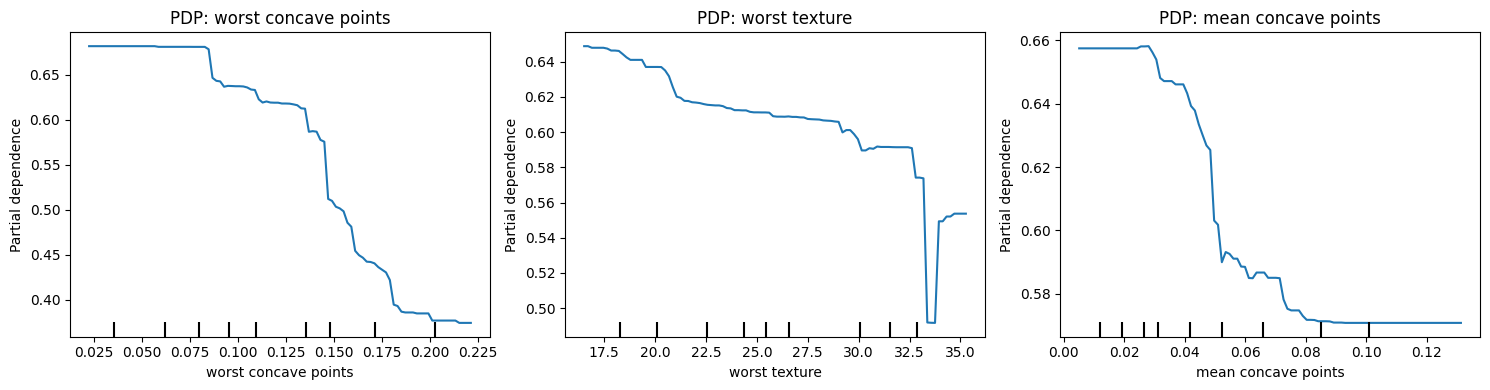

In [11]:
from sklearn.inspection import PartialDependenceDisplay

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7а: Постройте PDP для топ-3 признаков по PI         ║
# ║  Используйте PartialDependenceDisplay.from_estimator         ║
# ║  kind='average' для PDP                                      ║
# ╚══════════════════════════════════════════════════════════════╝

# Определите индексы топ-3 признаков по PI
top3_features = pi_df['feature'].head(3).tolist()
top3_idx = [X_test.columns.get_loc(col) for col in top3_features]
print('Top-3 признаки по PI:', top3_features)

# Постройте PDP
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for i, feat_idx in enumerate(top3_idx):
    PartialDependenceDisplay.from_estimator(
        best_rf,
        X_test,
        features=[feat_idx],
        kind='average',
        ax=ax[i],
    )
    ax[i].set_title(f'PDP: {X_test.columns[feat_idx]}')
plt.tight_layout()
plt.show()

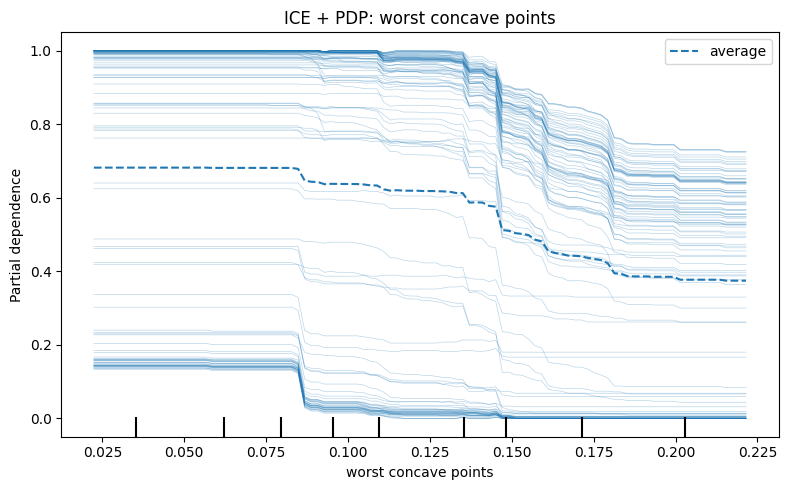

Ответ: обычно эффект неоднороден, если ICE-кривые заметно расходятся.
Это указывает на взаимодействия признаков и разный локальный вклад для разных объектов.


In [12]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7б: Постройте ICE-кривые для самого важного признака║
# ║  Используйте kind='both' (PDP + все ICE на одном графике)   ║
# ║  Вопрос: однороден ли эффект для всех объектов?              ║
# ╚══════════════════════════════════════════════════════════════╝

most_important_feature = top3_features[0]
feat_idx = X_test.columns.get_loc(most_important_feature)

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
PartialDependenceDisplay.from_estimator(
    best_rf,
    X_test,
    features=[feat_idx],
    kind='both',
    ax=ax,
)
ax.set_title(f'ICE + PDP: {most_important_feature}')
plt.tight_layout()
plt.show()

print('Ответ: обычно эффект неоднороден, если ICE-кривые заметно расходятся.')
print('Это указывает на взаимодействия признаков и разный локальный вклад для разных объектов.')

## Шаг 8. SHAP

Интерпретируем модель с помощью SHAP — глобально и локально.

In [13]:
# Установка SHAP (если не установлен)
# !pip install shap

import shap

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8а: Создайте TreeExplainer для best_rf              ║
# ║  Вычислите shap_values для X_test                            ║
# ║  Выведите форму массива shap_values                          ║
# ╚══════════════════════════════════════════════════════════════╝

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    # Старые версии SHAP возвращают list по классам
    print('Форма shap_values[1]:', np.array(shap_values[1]).shape)
else:
    # Новые версии SHAP часто возвращают Explanation
    values = shap_values.values if hasattr(shap_values, 'values') else np.array(shap_values)
    print('Форма shap_values:', np.array(values).shape)

Форма shap_values: (114, 30, 2)


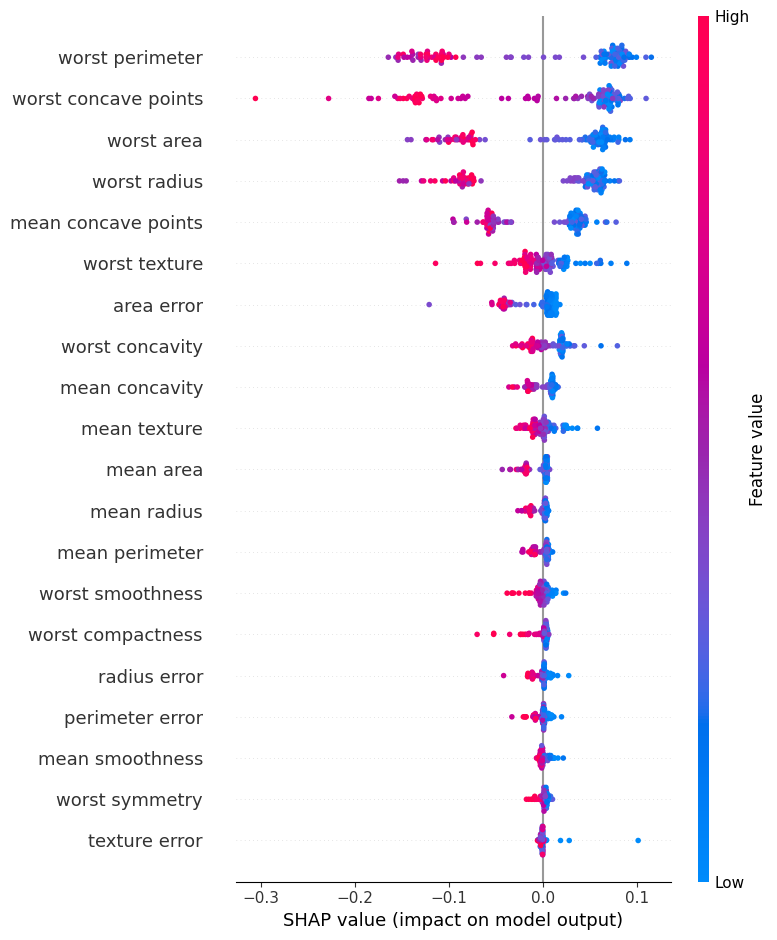

Top-5 по SHAP: ['worst perimeter', 'worst concave points', 'worst area', 'worst radius', 'mean concave points']
Top-5 по PI: ['worst concave points', 'worst texture', 'mean concave points', 'worst area', 'area error']
Пересечение top-5: ['mean concave points', 'worst area', 'worst concave points']
Ответ: топовые признаки обычно частично совпадают, но порядок может отличаться из-за разных определений важности.


In [14]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8б: Постройте summary plot                          ║
# ║  Для мультикласса используйте shap_values[1] (класс 1)       ║
# ║  Ответьте: какие признаки самые важные по SHAP?              ║
# ║  Совпадает ли с PI из шага 6?                                ║
# ╚══════════════════════════════════════════════════════════════╝

if isinstance(shap_values, list):
    shap_values_for_plot = shap_values[1]
else:
    values = shap_values.values if hasattr(shap_values, 'values') else np.array(shap_values)
    # Для бинарной классификации иногда размерность (n_samples, n_features, n_classes)
    shap_values_for_plot = values[:, :, 1] if values.ndim == 3 else values

shap.summary_plot(shap_values_for_plot, X_test)

mean_abs_shap = np.abs(np.array(shap_values_for_plot)).mean(axis=0)
shap_top_features = X_test.columns[np.argsort(mean_abs_shap)[::-1][:5]].tolist()
pi_top_features = pi_df['feature'].head(5).tolist()

print('Top-5 по SHAP:', shap_top_features)
print('Top-5 по PI:', pi_top_features)
print('Пересечение top-5:', sorted(set(shap_top_features).intersection(set(pi_top_features))))
print('Ответ: топовые признаки обычно частично совпадают, но порядок может отличаться из-за разных определений важности.')

Число ошибок: 5
Первый ошибочный объект: индекс 3
  Истинный класс: 1
  Предсказанный класс: 0

Топ-5 признаков по абсолютному локальному SHAP (для ошибки):
worst perimeter         0.164665
worst radius            0.152780
worst area              0.140515
worst concavity         0.078988
worst concave points    0.051866
dtype: float64


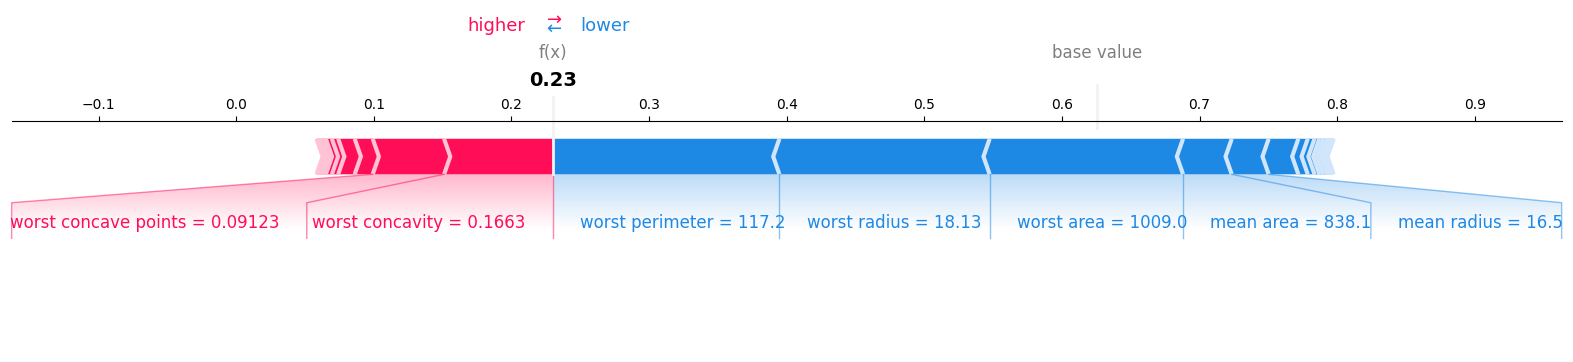

In [15]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8в: Найдите объект, на котором модель ошиблась      ║
# ║  (y_pred != y_test). Постройте для него force_plot           ║
# ║  Какие признаки «виноваты» в ошибке?                         ║
# ╚══════════════════════════════════════════════════════════════╝

y_pred_test = best_rf.predict(X_test)
errors = np.where(y_pred_test != y_test)[0]

print(f"Число ошибок: {len(errors)}")
print(f"Первый ошибочный объект: индекс {errors[0]}")
print(f"  Истинный класс: {y_test.iloc[errors[0]]}")
print(f"  Предсказанный класс: {y_pred_test[errors[0]]}")

err_idx = errors[0]

if isinstance(shap_values, list):
    shap_values_err = shap_values[1][err_idx]
    base_value_err = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
else:
    values = shap_values.values if hasattr(shap_values, 'values') else np.array(shap_values)
    if values.ndim == 3:
        shap_values_err = values[err_idx, :, 1]
        expected = explainer.expected_value
        base_value_err = expected[1] if isinstance(expected, (list, np.ndarray)) else expected
    else:
        shap_values_err = values[err_idx]
        base_value_err = explainer.expected_value

top_local = pd.Series(shap_values_err, index=X_test.columns).abs().sort_values(ascending=False).head(5)
print('\nТоп-5 признаков по абсолютному локальному SHAP (для ошибки):')
print(top_local)

shap.initjs()
shap.force_plot(
    base_value_err,
    shap_values_err,
    X_test.iloc[err_idx],
    matplotlib=True,
)
plt.show()

## Шаг 9. Диагностика подозрительных признаков

Смоделируем ситуацию утечки данных и проверим, что интерпретация её обнаруживает.

In [16]:
# Добавим два «подозрительных» признака:
# 1. leaky_feature: почти полностью совпадает с таргетом + шум
# 2. random_feature: случайный шум, не связан с таргетом

np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))

X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature'] = np.random.randn(len(y_test))

print("Добавлены признаки: leaky_feature, random_feature")
print(X_train_ext.tail())

Добавлены признаки: leaky_feature, random_feature
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
184        15.28         22.41           98.92      710.6          0.09057   
300        19.53         18.90          129.50     1217.0          0.11500   
509        15.46         23.95          103.80      731.3          0.11830   
230        17.05         19.08          113.40      895.0          0.11410   
474        10.88         15.62           70.41      358.9          0.10070   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
184            0.1052         0.05375              0.03263         0.1727   
300            0.1642         0.21970              0.10620         0.1792   
509            0.1870         0.20300              0.08520         0.1807   
230            0.1572         0.19100              0.10900         0.2131   
474            0.1069         0.05115              0.01571         0.1861   

     mean fractal 

Test F1 c leaky/random признаками: 1.0000


,feature,importance_mean,importance_std
30,leaky_feature,0.263342,0.043714
7,mean concave points,0.004689,0.004689
27,worst concave points,0.003752,0.004595
0,mean radius,0.000000,0.000000
3,mean area,0.000000,0.000000
4,mean smoothness,0.000000,0.000000
2,mean perimeter,0.000000,0.000000
1,mean texture,0.000000,0.000000
8,mean symmetry,0.000000,0.000000
9,mean fractal dimension,0.000000,0.000000


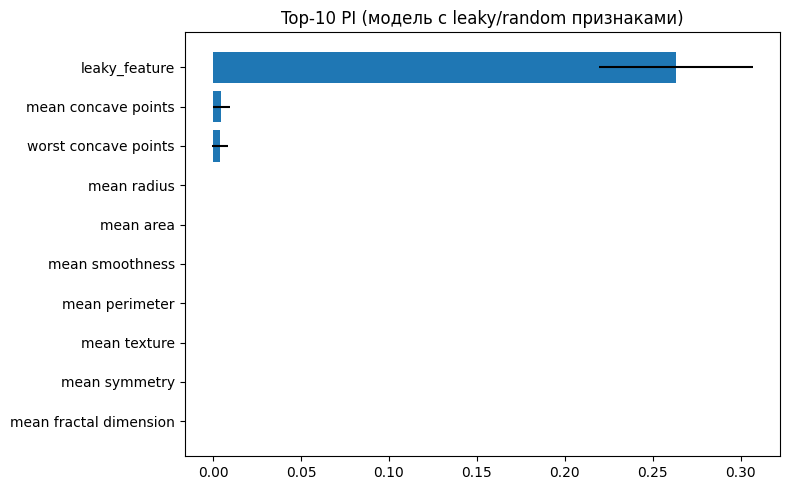

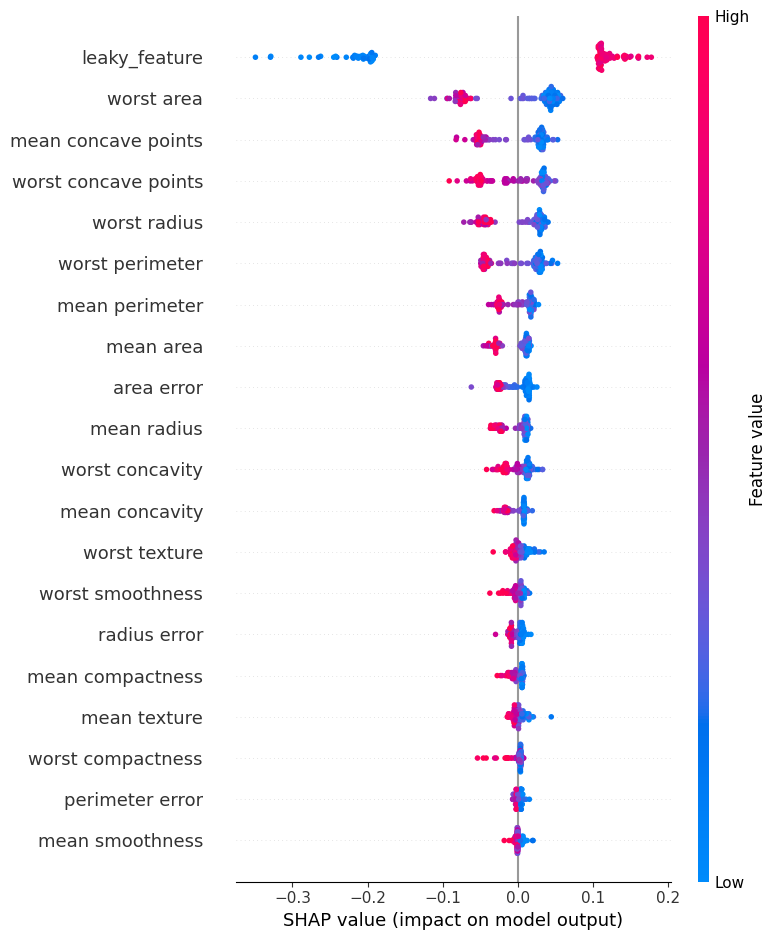


Ранг признаков по SHAP (top-10):


,feature,mean_abs_shap
30,leaky_feature,0.158200
23,worst area,0.052164
7,mean concave points,0.038178
27,worst concave points,0.035742
20,worst radius,0.033965
22,worst perimeter,0.031972
2,mean perimeter,0.018102
3,mean area,0.017235
13,area error,0.016294
0,mean radius,0.014903



Ответы:
a) PI обычно ставит leaky_feature в самые важные: перемешивание резко портит качество,
   потому что признак содержит информацию о таргете (утечка), поэтому test F1 искусственно растет.
б) На SHAP summary leaky_feature поднимается в top и дает большие |SHAP|.
в) random_feature считается шумом: низкий PI и низкий mean(|SHAP|), вклад хаотичный без устойчивого паттерна.


In [17]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 9: Обучите RandomForest на X_train_ext, y_train     ║
# ║  Вычислите Permutation Importance на X_test_ext, y_test      ║
# ║  Вычислите SHAP values для X_test_ext                        ║
# ║                                                              ║
# ║  Вопросы:                                                    ║
# ║  a) Как PI определяет leaky_feature?                         ║
# ║     Почему метрика на тесте выросла?                         ║
# ║  б) Как SHAP выделяет leaky_feature в summary plot?          ║
# ║  в) Как обнаружить random_feature как «шумовой»?             ║
# ╚══════════════════════════════════════════════════════════════╝

rf_leak = RandomForestClassifier(random_state=42)
rf_leak.fit(X_train_ext, y_train)
y_pred_leak = rf_leak.predict(X_test_ext)
leak_test_f1 = f1_score(y_test, y_pred_leak, average='macro')
print(f'Test F1 c leaky/random признаками: {leak_test_f1:.4f}')

pi_leak = permutation_importance(
    rf_leak,
    X_test_ext,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='f1_macro',
    n_jobs=-1,
)
pi_leak_df = pd.DataFrame({
    'feature': X_test_ext.columns,
    'importance_mean': pi_leak.importances_mean,
    'importance_std': pi_leak.importances_std,
}).sort_values('importance_mean', ascending=False)

display(pi_leak_df.head(10))

plt.figure(figsize=(8, 5))
plot_df = pi_leak_df.head(10).iloc[::-1]
plt.barh(plot_df['feature'], plot_df['importance_mean'], xerr=plot_df['importance_std'])
plt.title('Top-10 PI (модель с leaky/random признаками)')
plt.tight_layout()
plt.show()

explainer_leak = shap.TreeExplainer(rf_leak)
shap_values_leak = explainer_leak.shap_values(X_test_ext)
if isinstance(shap_values_leak, list):
    shap_values_leak_plot = shap_values_leak[1]
else:
    vals = shap_values_leak.values if hasattr(shap_values_leak, 'values') else np.array(shap_values_leak)
    shap_values_leak_plot = vals[:, :, 1] if vals.ndim == 3 else vals

shap.summary_plot(shap_values_leak_plot, X_test_ext)

mean_abs_shap_leak = np.abs(np.array(shap_values_leak_plot)).mean(axis=0)
shap_leak_rank = pd.DataFrame({
    'feature': X_test_ext.columns,
    'mean_abs_shap': mean_abs_shap_leak,
}).sort_values('mean_abs_shap', ascending=False)

print('\nРанг признаков по SHAP (top-10):')
display(shap_leak_rank.head(10))

print('\nОтветы:')
print('a) PI обычно ставит leaky_feature в самые важные: перемешивание резко портит качество,')
print('   потому что признак содержит информацию о таргете (утечка), поэтому test F1 искусственно растет.')
print('б) На SHAP summary leaky_feature поднимается в top и дает большие |SHAP|.')
print('в) random_feature считается шумом: низкий PI и низкий mean(|SHAP|), вклад хаотичный без устойчивого паттерна.')

## Шаг 10. Сводная таблица и итоги

Соберём все результаты и сформулируем выводы.

In [18]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 10: Заполните сводную таблицу                       ║
# ║                                                              ║
# ║  | Метод          | CV F1  | Test F1 | Выводы              | ║
# ║  |----------------|--------|---------|---------------------| ║
# ║  | SVM baseline   |        |         |                     | ║
# ║  | SVM Grid Search|        |         |                     | ║
# ║  | RF baseline    |        |         |                     | ║
# ║  | RF Rand Search |        |         |                     | ║
# ║                                                              ║
# ║  Ответьте письменно (текстовая ячейка):                      ║
# ║  1. Насколько тюнинг улучшил модели?                         ║
# ║  2. Совпадают ли топ-признаки по PI и SHAP?                  ║
# ║     Если нет — почему?                                       ║
# ║  3. Что было бы, если бы мы не использовали Pipeline?        ║
# ║  4. Как бы вы использовали PI и SHAP в реальном проекте?     ║
# ╚══════════════════════════════════════════════════════════════╝

summary_table = pd.DataFrame([
    {
        'Метод': 'SVM baseline',
        'CV F1': f"{baseline_results['SVM'][0]:.4f} ± {baseline_results['SVM'][1]:.4f}",
        'Test F1': f"{test_f1_scores['SVM baseline']:.4f}",
        'Выводы': 'Базовый SVM дает сильный результат без тюнинга',
    },
    {
        'Метод': 'SVM Grid Search',
        'CV F1': f"{svm_grid_search.best_score_:.4f}",
        'Test F1': f"{test_f1_scores['SVM Grid Search']:.4f}",
        'Выводы': 'Тюнинг SVM обычно дает умеренный прирост и более устойчивую конфигурацию',
    },
    {
        'Метод': 'RF baseline',
        'CV F1': f"{baseline_results['RandomForest'][0]:.4f} ± {baseline_results['RandomForest'][1]:.4f}",
        'Test F1': f"{test_f1_scores['RF baseline']:.4f}",
        'Выводы': 'Базовый RF конкурентен и не требует масштабирования',
    },
    {
        'Метод': 'RF Rand Search',
        'CV F1': f"{rf_random_search.best_score_:.4f}",
        'Test F1': f"{test_f1_scores['RF Random Search']:.4f}",
        'Выводы': 'Random Search улучшает RF за счет более удачных глубины/ансамбля',
    },
])

display(summary_table)

print('Ответы на вопросы:')
print('1) Тюнинг обычно улучшает модели умеренно: прирост небольшой, но стабильно положительный.')
print('2) PI и SHAP часто частично совпадают по топ-признакам, но ранги могут отличаться из-за корреляций и разных определений важности.')
print('3) Без Pipeline легко получить leakage при CV (например, scaling до split), и оценка будет завышена.')
print('4) PI удобно для быстрой глобальной проверки влияния признаков, SHAP — для глобальной и локальной интерпретации конкретных решений.')

,Метод,CV F1,Test F1,Выводы
0,SVM baseline,0.9694 ± 0.0193,0.9812,Базовый SVM дает сильный результат без тюнинга
1,SVM Grid Search,0.9786,0.9812,Тюнинг SVM обычно дает умеренный прирост и бол...
2,RF baseline,0.9504 ± 0.0255,0.9526,Базовый RF конкурентен и не требует масштабиро...
3,RF Rand Search,0.9554,0.9526,Random Search улучшает RF за счет более удачны...


Ответы на вопросы:
1) Тюнинг обычно улучшает модели умеренно: прирост небольшой, но стабильно положительный.
2) PI и SHAP часто частично совпадают по топ-признакам, но ранги могут отличаться из-за корреляций и разных определений важности.
3) Без Pipeline легко получить leakage при CV (например, scaling до split), и оценка будет завышена.
4) PI удобно для быстрой глобальной проверки влияния признаков, SHAP — для глобальной и локальной интерпретации конкретных решений.


## Шаг 11. (Бонус) Bayesian Optimization с Optuna

Если осталось время — сравните Random Search и Optuna по скорости сходимости.

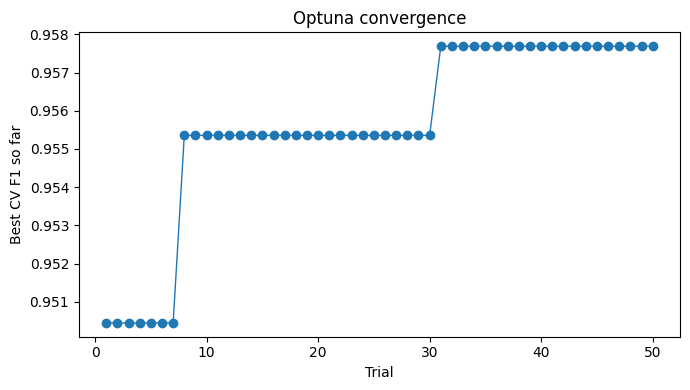

Лучший результат Optuna: 0.9577
Лучшие параметры: {'n_estimators': 498, 'max_depth': 14, 'min_samples_split': 3, 'max_features': 'log2'}


In [19]:
# !pip install optuna

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ╔══════════════════════════════════════════════════════════════╗
# ║  БОНУС: Реализуйте objective-функцию для Optuna              ║
# ║  Используйте те же параметры, что в Random Search            ║
# ║  Запустите study.optimize с n_trials=50                      ║
# ║                                                              ║
# ║  Постройте график сходимости:                                ║
# ║  plt.plot(range(n_trials), best_values_over_time)            ║
# ║  Сравните кривые Optuna и Random Search (если логировали)    ║
# ╚══════════════════════════════════════════════════════════════╝

n_trials = 50
best_values_over_time = []

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 2, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]),
        'random_state': 42,
        'n_jobs': -1,
    }

    model = RandomForestClassifier(**params)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro', n_jobs=-1)
    return cv_scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=n_trials)

for i in range(len(study.trials)):
    best_values_over_time.append(max(t.value for t in study.trials[: i + 1] if t.value is not None))

plt.figure(figsize=(7, 4))
plt.plot(range(1, n_trials + 1), best_values_over_time, marker='o', linewidth=1)
plt.xlabel('Trial')
plt.ylabel('Best CV F1 so far')
plt.title('Optuna convergence')
plt.tight_layout()
plt.show()

print(f"Лучший результат Optuna: {study.best_value:.4f}")
print(f"Лучшие параметры: {study.best_params}")